# 06 — MobileNet-V2 (pretrained ImageNet)

In [2]:
import sys
import time
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path

from eval import LABEL_ORDER
from utils import (
    set_seed, load_dataset, split_dataset,
    get_train_transform, get_eval_transform, build_dataloaders,
    train_model, save_checkpoint, load_checkpoint,
    plot_training_history, print_model_info,
    compute_multilabel_metrics, evaluate_predictor,
    print_metric_table, NUM_LABELS, METRIC_KEYS,
)

SEED = 42
set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Labels ({NUM_LABELS}): {LABEL_ORDER}")


Device: cuda
Labels (12): ['pen', 'paper', 'book', 'clock', 'phone', 'laptop', 'chair', 'desk', 'bottle', 'keychain', 'backpack', 'calculator']


In [3]:
BASE_DIR        = "../data/aggregated"
IMAGE_SIZE      = 224
BATCH_SIZE      = 128
SPLIT           = [0.7, 0.15, 0.15]
CHECKPOINT_DIR  = Path("../checkpoints")
EXPERIMENT_NAME = "mobilenetv2_pretrained"
MODEL_PATH      = CHECKPOINT_DIR / f"final_{EXPERIMENT_NAME}.pth"

full_dataset = load_dataset(BASE_DIR)
train_raw, val_raw, test_raw = split_dataset(full_dataset, SPLIT, SEED)

train_transform = get_train_transform(IMAGE_SIZE)
eval_transform  = get_eval_transform(IMAGE_SIZE)
train_loader, val_loader, test_loader = build_dataloaders(
    train_raw, val_raw, test_raw, train_transform, eval_transform,
    batch_size=BATCH_SIZE,
)
print(f"Train: {len(train_raw)}  |  Val: {len(val_raw)}  |  Test: {len(test_raw)}")


Train: 3180  |  Val: 681  |  Test: 682


## Model Definition

In [4]:
from torchvision import models as tv_models

def create_model(num_labels):
    m = tv_models.mobilenet_v2(weights=tv_models.MobileNet_V2_Weights.IMAGENET1K_V2)
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, num_labels)
    return m

print_model_info(create_model(NUM_LABELS))


  Total params     :    2,239,244
  Trainable params :    2,239,244  (100.0%)
  Model size       : 8.54 MB  (float32 weights)


## Grid Search (LR × WD)

In [5]:
GRID = [
    {"lr": 1e-3, "wd": 1e-4},
    {"lr": 1e-4, "wd": 1e-4},
]

grid_results = []
for cfg in GRID:
    print(f"\n--- lr={cfg['lr']:.0e}  wd={cfg['wd']:.0e} ---")
    state, val_f1, _, epochs_run = train_model(
        create_model, NUM_LABELS, train_loader, val_loader, DEVICE,
        lr=cfg["lr"], weight_decay=cfg["wd"],
        max_epochs=20, warmup_epochs=2, early_stop_patience=5,
    )
    grid_results.append({**cfg, "val_f1": val_f1, "state": state, "epochs": epochs_run})
    print(f"  => val F1: {val_f1:.4f}")

grid_results.sort(key=lambda x: x["val_f1"], reverse=True)
best = grid_results[0]
print(f"\nBest config: lr={best['lr']:.0e}  wd={best['wd']:.0e}  val_F1={best['val_f1']:.4f}")

rows = [{"lr": c["lr"], "wd": c["wd"], "val_f1": round(c["val_f1"], 4), "epochs": c["epochs"]}
        for c in grid_results]
print(pd.DataFrame(rows).to_string(index=False))



--- lr=1e-03  wd=1e-04 ---

Epoch  1/20  [lr=5.00e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.4085    0.2687
  exact_match            0.0792    0.2056
  hamming_acc            0.8405    0.8888
  mean_iou               0.1310    0.3151
  precision_micro        0.3733    0.9477
  recall_micro           0.1296    0.2567
  f1_micro               0.1924    0.4039

Epoch  2/20  [lr=1.00e-03]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.2129    0.1778
  exact_match            0.4053    0.5286
  hamming_acc            0.9212    0.9415
  mean_iou               0.6008    0.7199
  precision_micro        0.8729    0.8898
  recall_micro           0.5413    0.6867
  f1_micro               0.6682    0.7752

Epoch  3/20  [lr=1.00e-03]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.1513    0.1578
  e

## Final Training


Epoch  1/60  [lr=2.00e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.5376    0.4070
  exact_match            0.0387    0.0822
  hamming_acc            0.7854    0.8661
  mean_iou               0.0964    0.1208
  precision_micro        0.1969    0.9492
  recall_micro           0.1505    0.0933
  f1_micro               0.1706    0.1700

Epoch  2/60  [lr=4.00e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.3021    0.2316
  exact_match            0.1648    0.3040
  hamming_acc            0.8834    0.9059
  mean_iou               0.2638    0.4757
  precision_micro        0.9225    0.9136
  recall_micro           0.2234    0.3967
  f1_micro               0.3597    0.5532

Epoch  3/60  [lr=6.00e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.2048    0.1736
  exact_match            0.4245

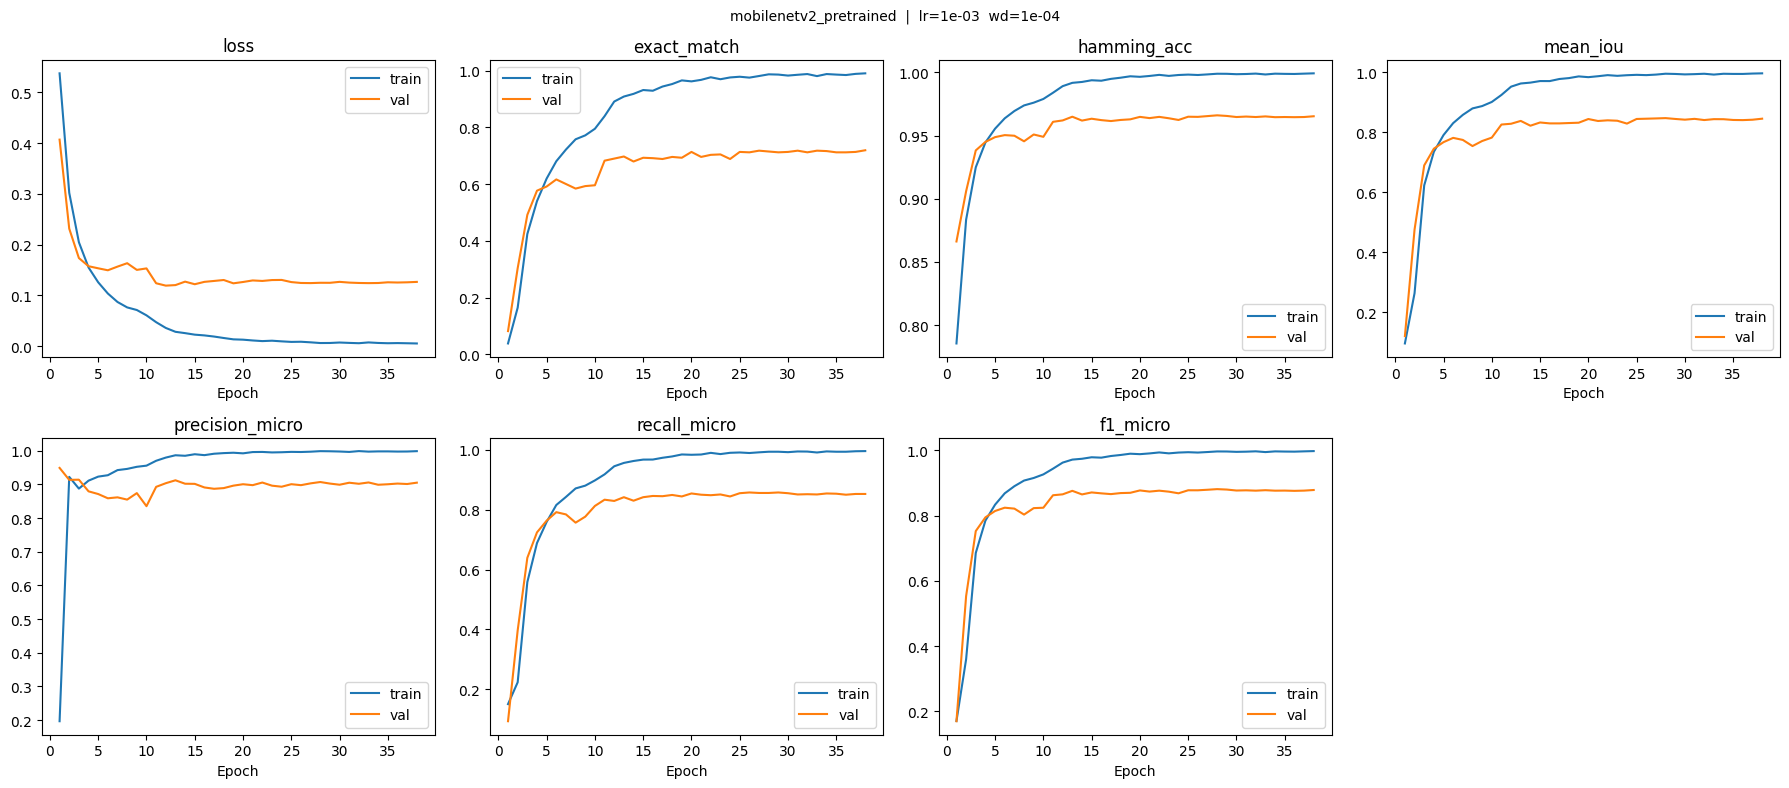

In [6]:
t0 = time.time()
best_state, best_val_f1, history, epochs_run = train_model(
    create_model, NUM_LABELS, train_loader, val_loader, DEVICE,
    lr=best["lr"], weight_decay=best["wd"],
    max_epochs=60, warmup_epochs=5, early_stop_patience=10,
)
training_time = time.time() - t0
print(f"\nBest val F1: {best_val_f1:.4f}  |  Epochs: {epochs_run}  |  Time: {training_time:.1f}s")

save_checkpoint(best_state, MODEL_PATH)
plot_training_history(history, epochs_run, EXPERIMENT_NAME, best["lr"], best["wd"])


## Evaluation

In [7]:
model = load_checkpoint(create_model, NUM_LABELS, MODEL_PATH, DEVICE)
model.eval()

def _predict(images, threshold=0.5):
    with torch.no_grad():
        logits = model(images)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= threshold).float()
    return preds, probs, logits

val_metrics  = evaluate_predictor(val_loader,  _predict, DEVICE)
test_metrics = evaluate_predictor(test_loader, _predict, DEVICE)

rows = [
    {"split": "val",  **{k: round(val_metrics[k],  4) for k in METRIC_KEYS}},
    {"split": "test", **{k: round(test_metrics[k], 4) for k in METRIC_KEYS}},
]
df = pd.DataFrame(rows).set_index("split")
print(df.to_string())


         loss  exact_match  hamming_acc  mean_iou  precision_micro  recall_micro  f1_micro
split                                                                                     
val    0.1249       0.7151        0.966    0.8471           0.9072        0.8558    0.8808
test   0.1401       0.7053        0.962    0.8281           0.9067        0.8237    0.8632


In [8]:

print("\nModel summary:")
print_model_info(create_model(NUM_LABELS))
print(f"Training time : {training_time:.1f}s")



Model summary:
  Total params     :    2,239,244
  Trainable params :    2,239,244  (100.0%)
  Model size       : 8.54 MB  (float32 weights)
Training time : 685.5s
